# Name -PRABAL GHOSH

## DATASET =  breast_proteomics_expression.csv

### LAB - OMICS 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline




In [2]:
df = pd.read_csv("breast_proteomics_expression.csv")
df.head()

,Unnamed: 0,Label,AGID00100,AGID00111,AGID00101,AGID00001,AGID00002,AGID00003,AGID00443,AGID00120,...,AGID00349,AGID02137,AGID00088,AGID00089,AGID00504,AGID00095,AGID02217,AGID02210,AGID00326,AGID00432
0,TCGA-C8-A26W-01A,1,0.266130,0.400270,-0.676650,-0.516900,-0.331410,0.146250,0.178840,-0.86514,...,0.196953,0.150710,0.373290,0.214090,-0.328940,-0.029406,-1.517599,-1.559424,0.885328,0.671174
1,TCGA-E9-A1RH-01A,1,1.025800,-0.033118,0.185060,-0.435040,-0.518890,0.098646,-0.216590,-1.30890,...,0.103434,-0.254290,0.202520,-0.043146,-0.089942,0.077988,-1.692018,-1.021853,1.330089,0.497645
2,TCGA-BH-A1EV-01A,1,-0.118660,-0.183975,-0.100580,0.392855,0.048953,0.069223,0.107047,0.16344,...,0.125252,-0.209415,-0.070309,0.645640,0.520730,-0.013806,-0.332210,0.403695,-1.266112,0.095263
3,TCGA-AO-A0JJ-01A,1,0.254110,-0.018340,-0.088122,-0.128520,-0.614090,-0.810440,-0.303180,-0.57081,...,0.082288,0.102540,-0.100130,-0.447700,-0.166140,-0.322580,-0.479464,-0.818679,1.593393,0.194719
4,TCGA-BH-A1FR-01A,1,0.069267,0.036387,-0.373775,0.263995,0.303891,0.253465,0.014739,0.58944,...,0.000000,-0.263760,-0.501035,-0.833835,-0.112917,-0.029290,0.000000,0.000000,0.000000,0.000000


In [3]:
df = df.drop(df.columns[0], axis=1)



In [4]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
from collections import Counter

class_counts = Counter(y)
print(class_counts)


Counter({1: 881, 0: 33})


<Axes: title={'center': 'Class Distribution'}, xlabel='Label'>

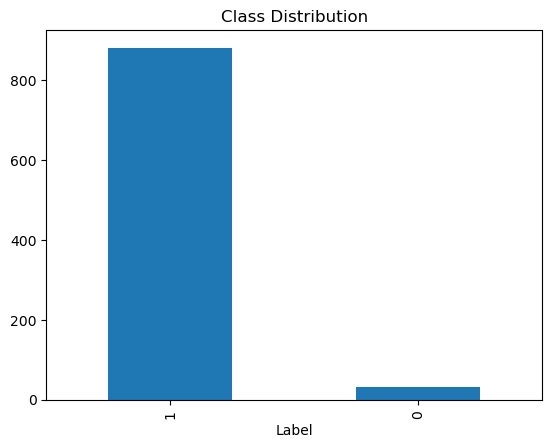

In [6]:
import pandas as pd
pd.Series(y).value_counts().plot(kind='bar', title='Class Distribution')


In [7]:
total_samples = len(y)
for label, count in class_counts.items():
    print(f'Class {label}: {count/total_samples:.2%}')


Class 1: 96.39%
Class 0: 3.61%


### imbalance class

### RandomOverSampler is used to balance the data by oversampling the minority class 

**RandomOverSampler is used on X_train and y_train to balance the training data.**
 - It's important to use resampling techniques like RandomOverSampler on the training data rather than the original data to avoid data leakage. This ensures that the model is trained on balanced data while maintaining the integrity of the validation and test datasets. Data leakage can occur when information from the validation or test sets inadvertently influences the training process, leading to overly optimistic performance estimates. Resampling techniques applied solely to the training data help mitigate this risk by ensuring that the model learns from balanced representations of each class without peeking at unseen data during training.

Label
1    704
0    300
Name: count, dtype: int64

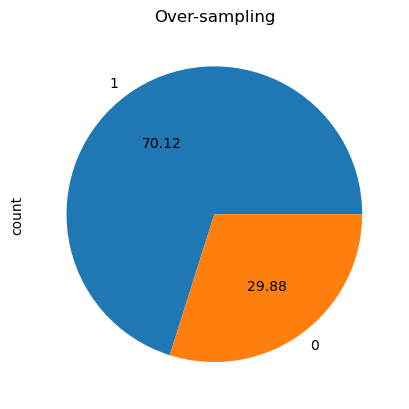

In [8]:
from imblearn.over_sampling import RandomOverSampler


# desired number of samples for the minority class
desired_minority_samples = 300  
minority_class_label = 0


# Create a dictionary with the desired sampling strategy
sampling_strategy = {minority_class_label : desired_minority_samples}

# RandomOverSampler with the specified sampling strategy
ros = RandomOverSampler(sampling_strategy=sampling_strategy)

X_train_transformed_resampled, y_train_resampled = ros.fit_resample(X_train_scaled, y_train)

ax = y_train_resampled.value_counts().plot.pie(autopct='%.2f')
_ = ax.set_title("Over-sampling")
y_train_resampled.value_counts()

In [9]:
X_train_scaled = X_train_transformed_resampled
y_train = y_train_resampled

## Feature Selection Methods:

###  Calculate information gain

In [10]:
from sklearn.feature_selection import mutual_info_classif

info_gain = mutual_info_classif(X_train_scaled, y_train)
selected_features_info_gain = X.columns[info_gain > 0.01]  # Threshold for selection

print(selected_features_info_gain)

Index(['AGID00100', 'AGID00111', 'AGID00101', 'AGID00001', 'AGID00002',
       'AGID00003', 'AGID00443', 'AGID00120', 'AGID00004', 'AGID00005',
       ...
       'AGID00349', 'AGID02137', 'AGID00088', 'AGID00089', 'AGID00504',
       'AGID00095', 'AGID02217', 'AGID02210', 'AGID00326', 'AGID00432'],
      dtype='object', length=464)


### Select top 100 features using ANOVA F-value

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=100)
X_train_kbest = selector_kbest.fit_transform(X_train_scaled, y_train)
X_test_kbest = selector_kbest.transform(X_test_scaled)

selected_features_kbest = X.columns[selector_kbest.get_support()]
print(selected_features_kbest)

Index(['AGID00347', 'AGID02215', 'AGID00287', 'AGID00309', 'AGID00310',
       'AGID02142', 'AGID02145', 'AGID00268', 'AGID00302', 'AGID00010',
       'AGID00219', 'AGID00377', 'AGID00355', 'AGID00266', 'AGID00016',
       'AGID00358', 'AGID00191', 'AGID00227', 'AGID00501', 'AGID00293',
       'AGID00447', 'AGID00167', 'AGID00269', 'AGID00150', 'AGID00365',
       'AGID00209', 'AGID00247', 'AGID00304', 'AGID00343', 'AGID00428',
       'AGID02146', 'AGID00407', 'AGID00399', 'AGID00409', 'AGID00235',
       'AGID02213', 'AGID00305', 'AGID00270', 'AGID00263', 'AGID00387',
       'AGID00174', 'AGID00033', 'AGID00397', 'AGID00332', 'AGID00333',
       'AGID00036', 'AGID00197', 'AGID00336', 'AGID02221', 'AGID00519',
       'AGID00256', 'AGID00375', 'AGID00198', 'AGID00362', 'AGID00337',
       'AGID02212', 'AGID00321', 'AGID00322', 'AGID00389', 'AGID00402',
       'AGID00122', 'AGID00331', 'AGID00340', 'AGID00087', 'AGID00162',
       'AGID00224', 'AGID00323', 'AGID00245', 'AGID00274', 'AGID

In [77]:
# X_train_kbest

### Recursive feature elimination

In [13]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

#  RFE with Random Forest
rfe = RFE(estimator=RandomForestClassifier(), n_features_to_select=20)
X_train_rfe = rfe.fit_transform(X_train_scaled, y_train)
X_test_rfe = rfe.transform(X_test_scaled)
selected_features_rfe = X.columns[rfe.support_]
print(selected_features_rfe)

Index(['AGID02145', 'AGID00010', 'AGID00016', 'AGID00358', 'AGID00399',
       'AGID00196', 'AGID00383', 'AGID00212', 'AGID00397', 'AGID00332',
       'AGID00198', 'AGID00331', 'AGID00226', 'AGID00207', 'AGID00306',
       'AGID00238', 'AGID00351', 'AGID00241', 'AGID02217', 'AGID00326'],
      dtype='object')


### missing value ratio

In [14]:
missing_ratio = X.isnull().mean()
print(missing_ratio)
selected_features_missing_ratio = X.columns[missing_ratio < 0.1]  # Threshold for selection
print(selected_features_missing_ratio)

AGID00100    0.0
AGID00111    0.0
AGID00101    0.0
AGID00001    0.0
AGID00002    0.0
            ... 
AGID00095    0.0
AGID02217    0.0
AGID02210    0.0
AGID00326    0.0
AGID00432    0.0
Length: 464, dtype: float64
Index(['AGID00100', 'AGID00111', 'AGID00101', 'AGID00001', 'AGID00002',
       'AGID00003', 'AGID00443', 'AGID00120', 'AGID00004', 'AGID00005',
       ...
       'AGID00349', 'AGID02137', 'AGID00088', 'AGID00089', 'AGID00504',
       'AGID00095', 'AGID02217', 'AGID02210', 'AGID00326', 'AGID00432'],
      dtype='object', length=464)


### Forward Selection

In [15]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Forward selection with Logistic Regression
forward_selector = SequentialFeatureSelector(
    LogisticRegression(), direction="forward", n_features_to_select=20
)
X_train_forward = forward_selector.fit_transform(X_train_scaled, y_train)
X_test_forward = forward_selector.transform(X_test_scaled)
selected_features_forward = X.columns[forward_selector.get_support()]
print(selected_features_forward)

Index(['AGID00100', 'AGID00111', 'AGID00101', 'AGID00001', 'AGID00002',
       'AGID00003', 'AGID00443', 'AGID00120', 'AGID00004', 'AGID00005',
       'AGID00408', 'AGID00473', 'AGID00404', 'AGID00377', 'AGID00373',
       'AGID00026', 'AGID00196', 'AGID00332', 'AGID00238', 'AGID00351'],
      dtype='object')


### L1 Regularization (Lasso)

In [16]:
from sklearn.linear_model import LassoCV

# Train Lasso to select features
lasso = LassoCV(cv=5, random_state=42)
lasso.fit(X_train_scaled, y_train)
selected_features_lasso = X.columns[lasso.coef_ != 0]
X_train_lasso = X_train_scaled[:, lasso.coef_ != 0]
X_test_lasso = X_test_scaled[:, lasso.coef_ != 0]


C:\Users\praba\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.154e+00, tolerance: 2.104e-02
  model = cd_fast.enet_coordinate_descent(


In [17]:
print(selected_features_lasso)

Index(['AGID00100', 'AGID00001', 'AGID00002', 'AGID00004', 'AGID00408',
       'AGID00473', 'AGID00404', 'AGID02144', 'AGID00170', 'AGID00316',
       ...
       'AGID00074', 'AGID00421', 'AGID00231', 'AGID00317', 'AGID00354',
       'AGID00285', 'AGID00133', 'AGID00089', 'AGID02210', 'AGID00326'],
      dtype='object', length=228)


### L1 Regularization (Lasso)

### PCA

In [18]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=0.90, svd_solver='full')
X_train_pca = pca_model.fit_transform(X_train_scaled)
X_test_pca = pca_model.transform(X_test_scaled)



In [19]:
X_train_pca.shape, X_test_pca.shape

((1004, 95), (183, 95))

In [20]:
pca_model.explained_variance_ratio_


array([0.29906725, 0.08418637, 0.06226476, 0.03947502, 0.03187282,
       0.02527532, 0.02193974, 0.01815359, 0.01720846, 0.01439146,
       0.01361955, 0.01271038, 0.01155075, 0.01094844, 0.01040141,
       0.00940552, 0.00861593, 0.00819649, 0.00728488, 0.00655201,
       0.00628031, 0.00596751, 0.00588342, 0.00573043, 0.00535212,
       0.00510385, 0.00487569, 0.00472915, 0.00457683, 0.00432149,
       0.00419353, 0.00397613, 0.00386681, 0.00365894, 0.00346574,
       0.00332637, 0.00328846, 0.00322562, 0.00315595, 0.0031076 ,
       0.00301726, 0.0028839 , 0.00284785, 0.0027826 , 0.00274908,
       0.00270488, 0.00262077, 0.00249998, 0.00246933, 0.00239309,
       0.00234467, 0.00227496, 0.00221696, 0.00216525, 0.00213013,
       0.00210287, 0.00206981, 0.00200276, 0.00198363, 0.00194279,
       0.00192579, 0.00186643, 0.00184566, 0.00181768, 0.00177281,
       0.00174858, 0.0017234 , 0.00166369, 0.0016344 , 0.00162222,
       0.00160945, 0.00158088, 0.00153235, 0.00151001, 0.00149

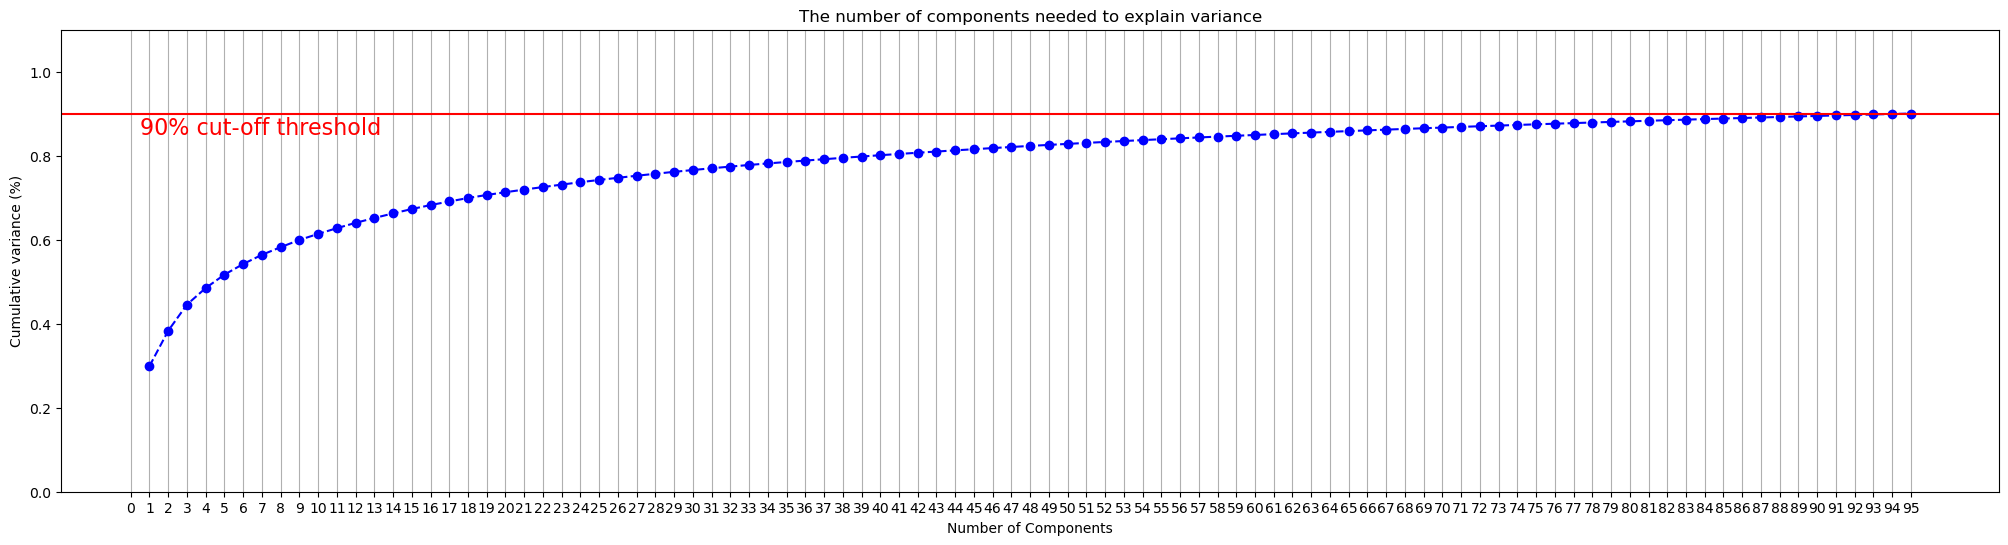

In [22]:
# % matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (25,6)

fig, ax = plt.subplots()
xi = np.arange(1, 96, step=1)   #  X_train_pca.shape =(1004, 95) thats why  1 am using 1 to 216
y = np.cumsum(pca_model.explained_variance_ratio_)

plt.ylim(0.0,1.1)
plt.plot(xi, y, marker='o', linestyle='--', color='b')

plt.xlabel('Number of Components')
plt.xticks(np.arange(0, 96, step=1)) #change from 0-based array index to 1-based human-readable label
plt.ylabel('Cumulative variance (%)')
plt.title('The number of components needed to explain variance')

plt.axhline(y=0.90, color='r', linestyle='-')
plt.text(0.5, 0.85, '90% cut-off threshold', color = 'red', fontsize=16)

ax.grid(axis='x')
plt.show()

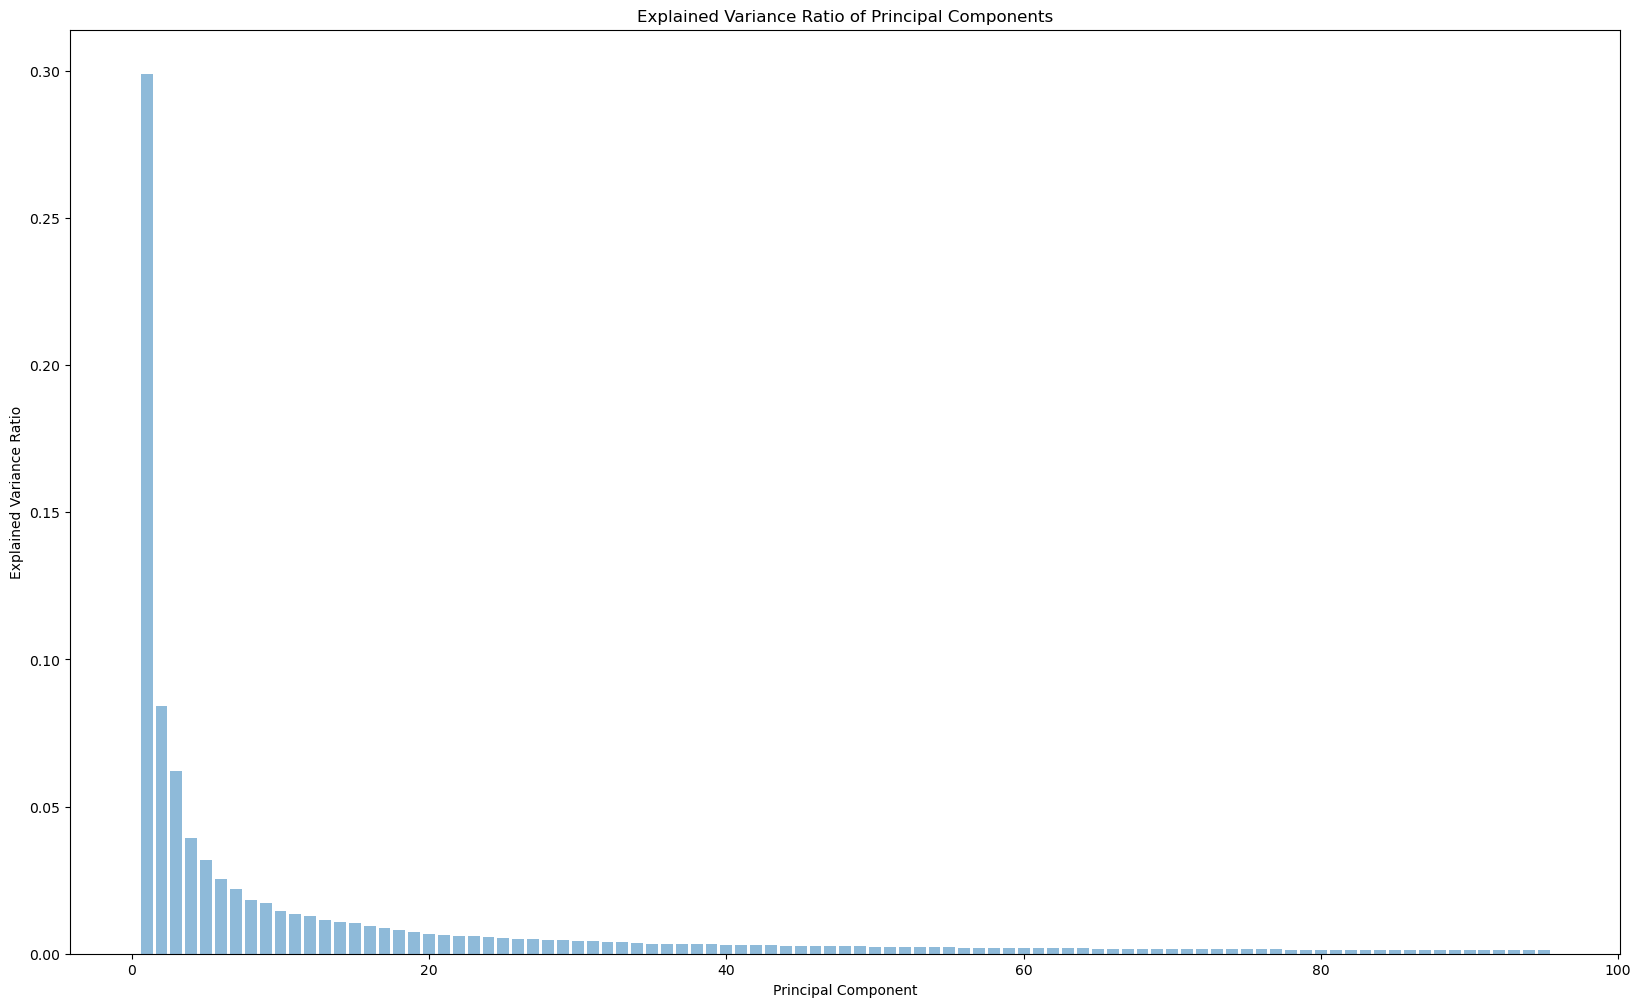

In [27]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler


# Plotting the explained variance ratio
plt.figure(figsize=(20, 12))
plt.bar(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, alpha=0.5, align='center')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio of Principal Components')
plt.show()

In [28]:
explained_variance = pca_model.explained_variance_ratio_
singular_values = pca_model.singular_values_

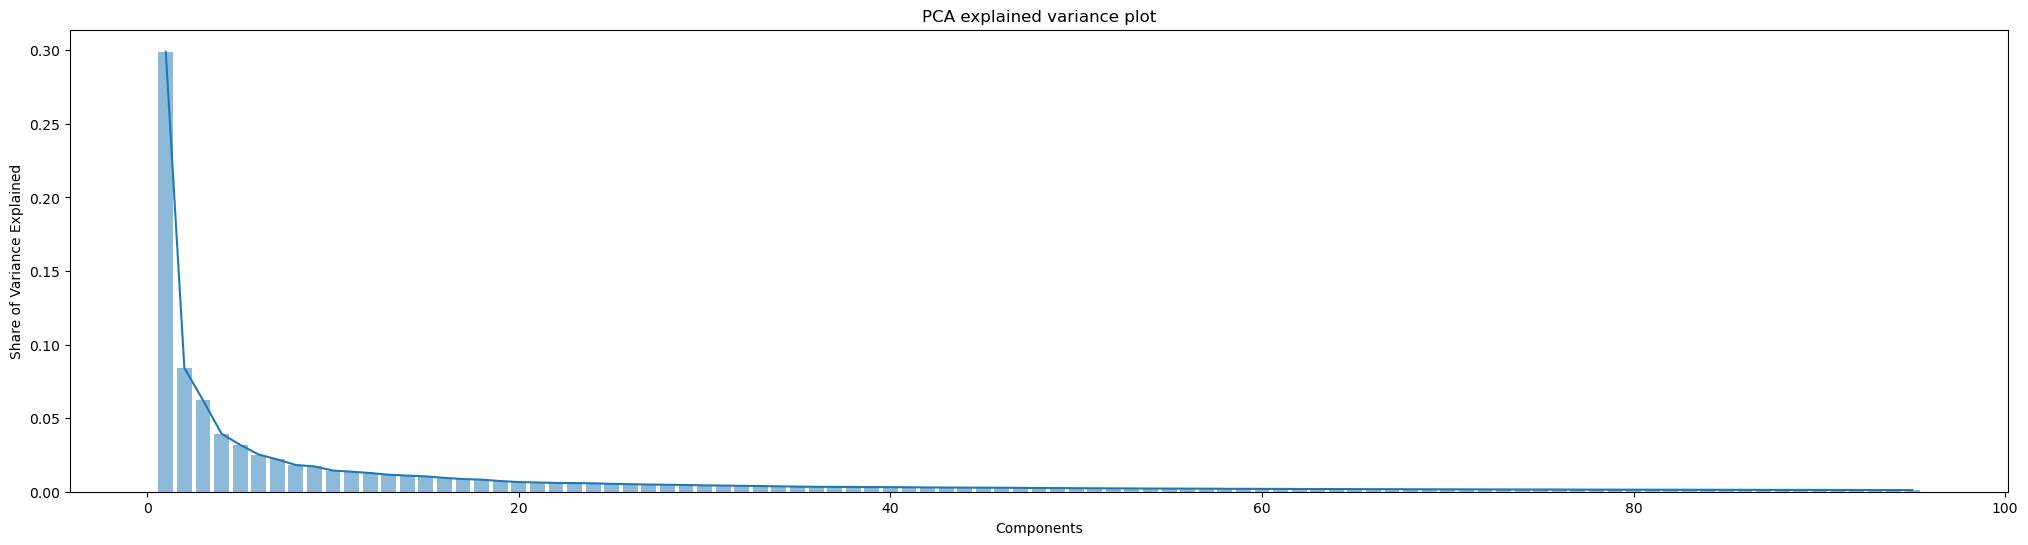

In [29]:
x = np.arange(1,len(explained_variance)+1)
plt.bar(range(1, len(pca_model.explained_variance_ratio_) + 1), pca_model.explained_variance_ratio_, alpha=0.5, align='center')

plt.plot(x, explained_variance)
plt.ylabel('Share of Variance Explained')
plt.title("PCA explained variance plot")
plt.xlabel("Components")
plt.show()

In [30]:
for i in range(0, 95):
    print(f"Component {i:>2} accounts for {explained_variance[i]*100:>2.2f}% of variance")

Component  0 accounts for 29.91% of variance
Component  1 accounts for 8.42% of variance
Component  2 accounts for 6.23% of variance
Component  3 accounts for 3.95% of variance
Component  4 accounts for 3.19% of variance
Component  5 accounts for 2.53% of variance
Component  6 accounts for 2.19% of variance
Component  7 accounts for 1.82% of variance
Component  8 accounts for 1.72% of variance
Component  9 accounts for 1.44% of variance
Component 10 accounts for 1.36% of variance
Component 11 accounts for 1.27% of variance
Component 12 accounts for 1.16% of variance
Component 13 accounts for 1.09% of variance
Component 14 accounts for 1.04% of variance
Component 15 accounts for 0.94% of variance
Component 16 accounts for 0.86% of variance
Component 17 accounts for 0.82% of variance
Component 18 accounts for 0.73% of variance
Component 19 accounts for 0.66% of variance
Component 20 accounts for 0.63% of variance
Component 21 accounts for 0.60% of variance
Component 22 accounts for 0.59%

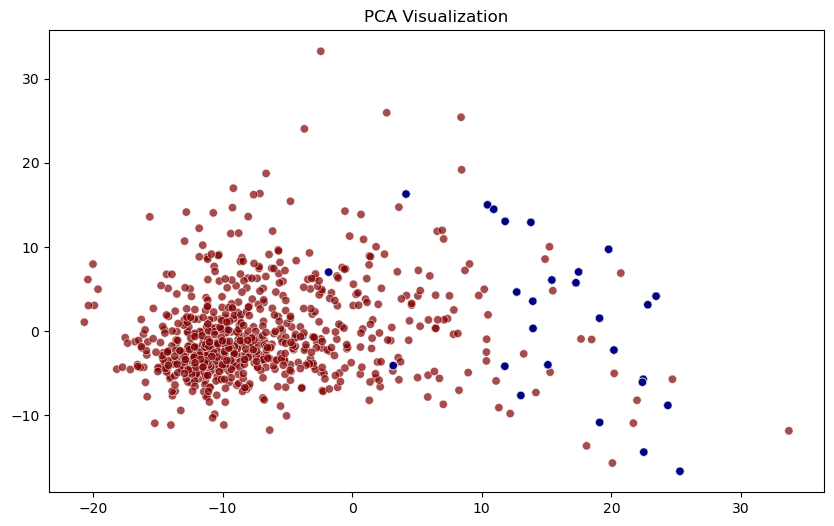

In [32]:
import seaborn as sns

# PCA Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], c=y_train, cmap='jet', alpha=0.7)
plt.title("PCA Visualization")
plt.show()


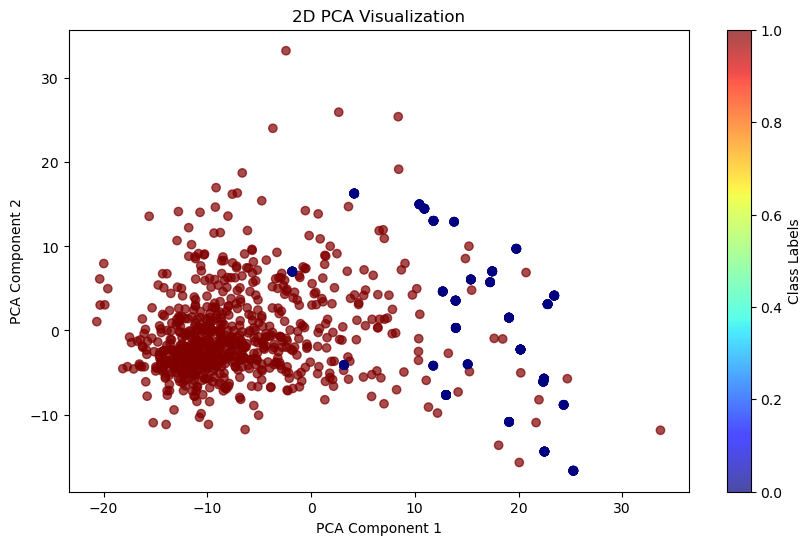

In [66]:
plt.figure(figsize=(10, 6))

plt.scatter(x=X_train_pca[:, 0], y=X_train_pca[:, 1], c=y_train, cmap='jet', alpha=0.7)


plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("2D PCA Visualization")
plt.colorbar(label="Class Labels")
plt.show()



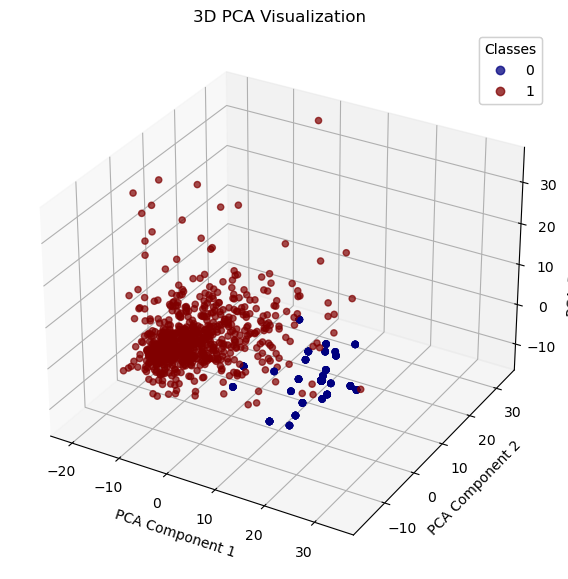

In [67]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("3D PCA Visualization")

# Add legend
legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()

####  For large datasets, first reduce dimensions with PCA before applying t-SNE ( if X has many features):


In [68]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_pca)

Text(0.5, 1.0, 't-SNE on PCA')

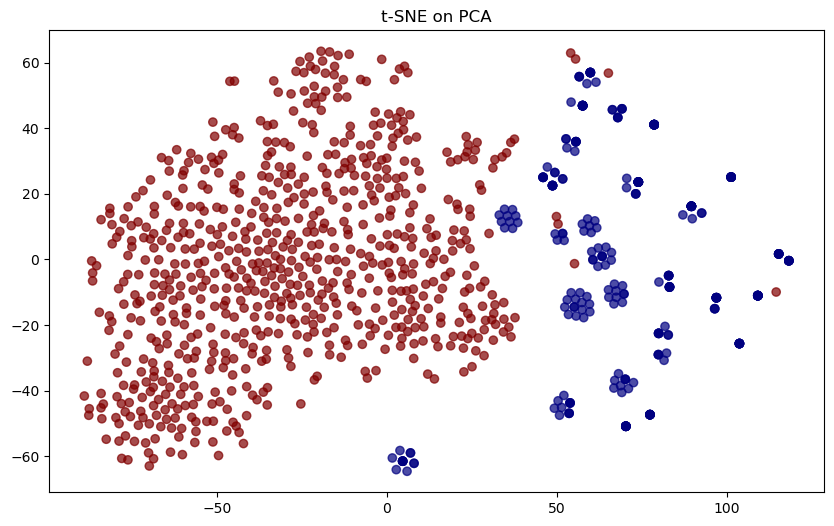

In [70]:
plt.figure(figsize=(10, 6))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='jet', alpha=0.7)
plt.title('t-SNE on PCA')


In [49]:
# t-SNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_train_pca)

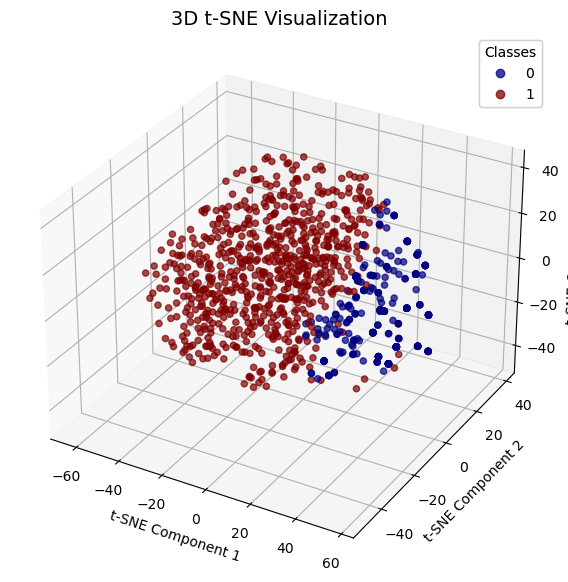

In [53]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_title("3D t-SNE Visualization", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
plt.show()


In [34]:
# from sklearn.mixture import GaussianMixture

# gmm = GaussianMixture(n_components=20, random_state=42)
# gmm.fit(X_train_scaled)
# X_train_mppca = gmm.predict_proba(X_train_scaled)
# X_test_mppca = gmm.predict_proba(X_test_scaled)

### Kernel PCA


In [35]:
from sklearn.decomposition import KernelPCA

kpca = KernelPCA(n_components=20, kernel="rbf", random_state=42)
X_train_kpca = kpca.fit_transform(X_train_scaled)
X_test_kpca = kpca.transform(X_test_scaled)

In [72]:
# plt.figure(figsize=(10, 6))

# plt.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], c=y_train, cmap='jet', alpha=0.7)
# plt.title('Kernel PCA')

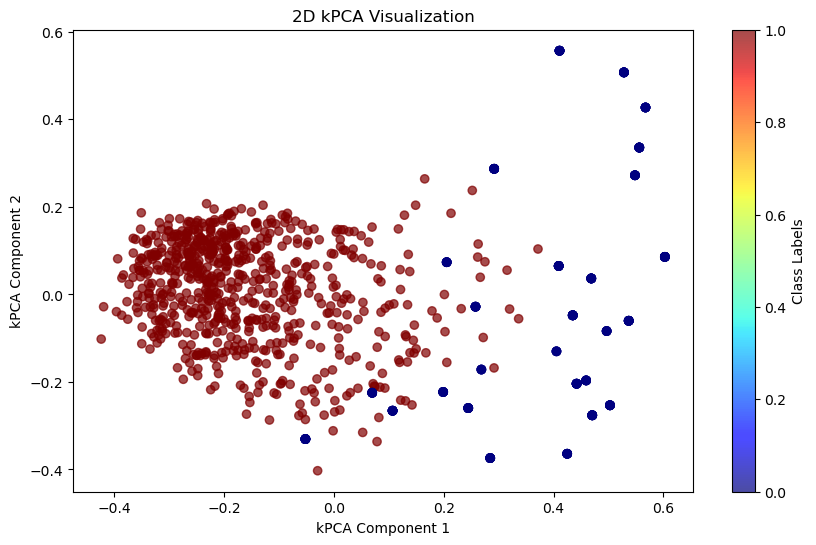

In [74]:
plt.figure(figsize=(10, 6))

plt.scatter(x=X_train_kpca[:, 0], y=X_train_kpca[:, 1], c=y_train, cmap='jet', alpha=0.7)


plt.xlabel("kPCA Component 1")
plt.ylabel("kPCA Component 2")
plt.title("2D kPCA Visualization")
plt.colorbar(label="Class Labels")
plt.show()



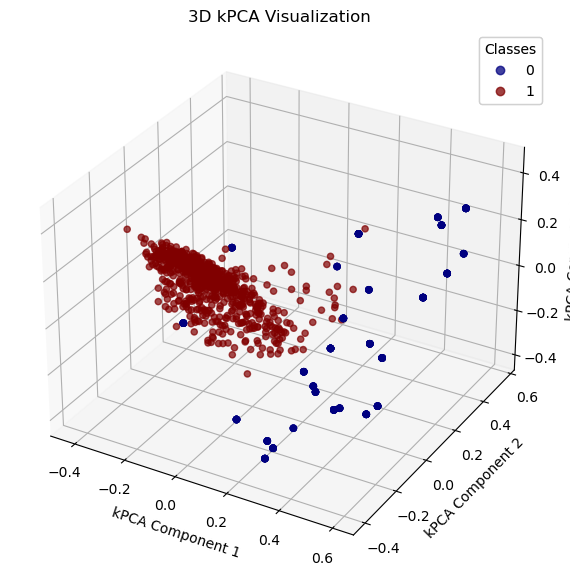

In [75]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_kpca[:, 0], X_train_kpca[:, 1], X_train_kpca[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_xlabel("kPCA Component 1")
ax.set_ylabel("kPCA Component 2")
ax.set_zlabel("kPCA Component 3")
ax.set_title("3D kPCA Visualization")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)

plt.show()

####  For large datasets, first reduce dimensions with PCA before applying t-SNE ( if X has many features):


In [55]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_train_kpca)

Text(0.5, 1.0, 't-SNE on Kernel PCA')

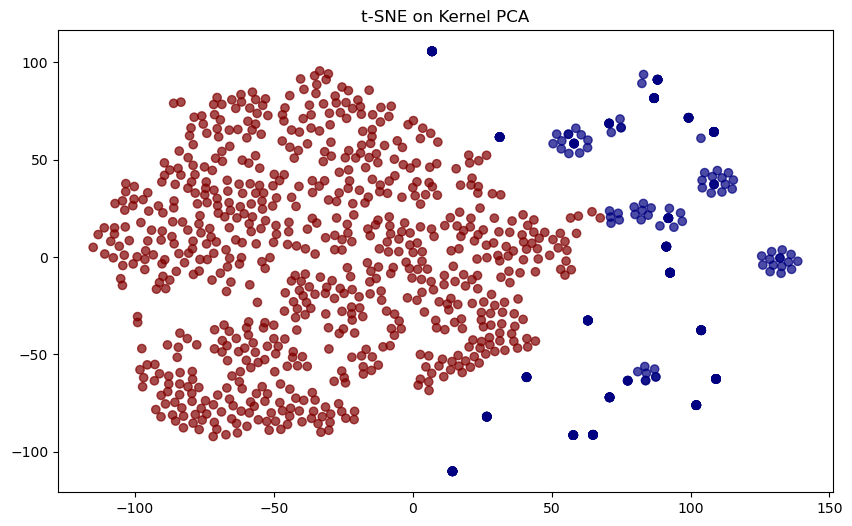

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_train, cmap='jet', alpha=0.7)
plt.title('t-SNE on Kernel PCA')


In [57]:
# t-SNE
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(X_train_kpca)

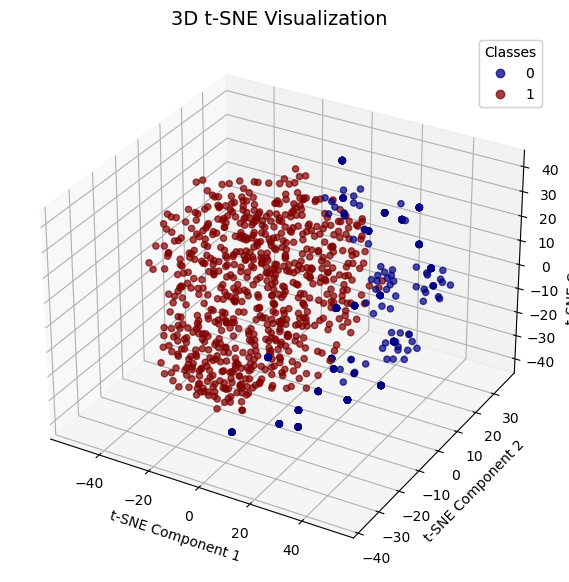

In [58]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne[:, 0], X_tsne[:, 1], X_tsne[:, 2], c=y_train, cmap='jet', alpha=0.7)

ax.set_title("3D t-SNE Visualization", fontsize=14)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")

legend1 = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend1)
plt.show()


## Classification:

### Logistic Regression

### Random Forest

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def evaluate_method(X_train, X_test, y_train, y_test, method_name):
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

    print(f"{method_name} - Logistic Regression Accuracy: {accuracy_lr:.4f}")
    print(f"{method_name} - Random Forest Accuracy: {accuracy_rf:.4f}")

# Evaluate all methods
evaluate_method(X_train_scaled, X_test_scaled, y_train, y_test, "Original Features")
evaluate_method(X_train_rfe, X_test_rfe, y_train, y_test, "RFE Features")

evaluate_method(X_train_lasso, X_test_lasso, y_train, y_test, "Lasso Features")
evaluate_method(X_train_pca, X_test_pca, y_train, y_test, "PCA Features")
evaluate_method(X_train_kpca, X_test_kpca, y_train, y_test, "KPCA Features")


Original Features - Logistic Regression Accuracy: 1.0000
Original Features - Random Forest Accuracy: 0.9945
RFE Features - Logistic Regression Accuracy: 1.0000
RFE Features - Random Forest Accuracy: 0.9945
Lasso Features - Logistic Regression Accuracy: 1.0000
Lasso Features - Random Forest Accuracy: 0.9945
PCA Features - Logistic Regression Accuracy: 1.0000
PCA Features - Random Forest Accuracy: 0.9836
KPCA Features - Logistic Regression Accuracy: 1.0000
KPCA Features - Random Forest Accuracy: 0.9836


## Feature Importance:

### Random Forest Feature Importance

### Lasso Coefficients

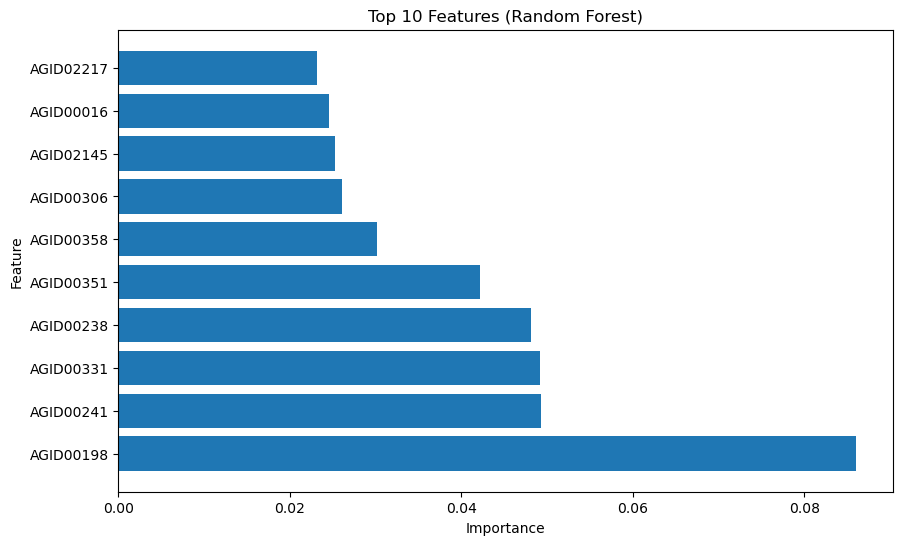

In [60]:
import matplotlib.pyplot as plt

# Train Random Forest on original features
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Plot top 10 important features
importances = rf.feature_importances_
sorted_idx = importances.argsort()[::-1][:10]

plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], importances[sorted_idx])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features (Random Forest)")
plt.show()

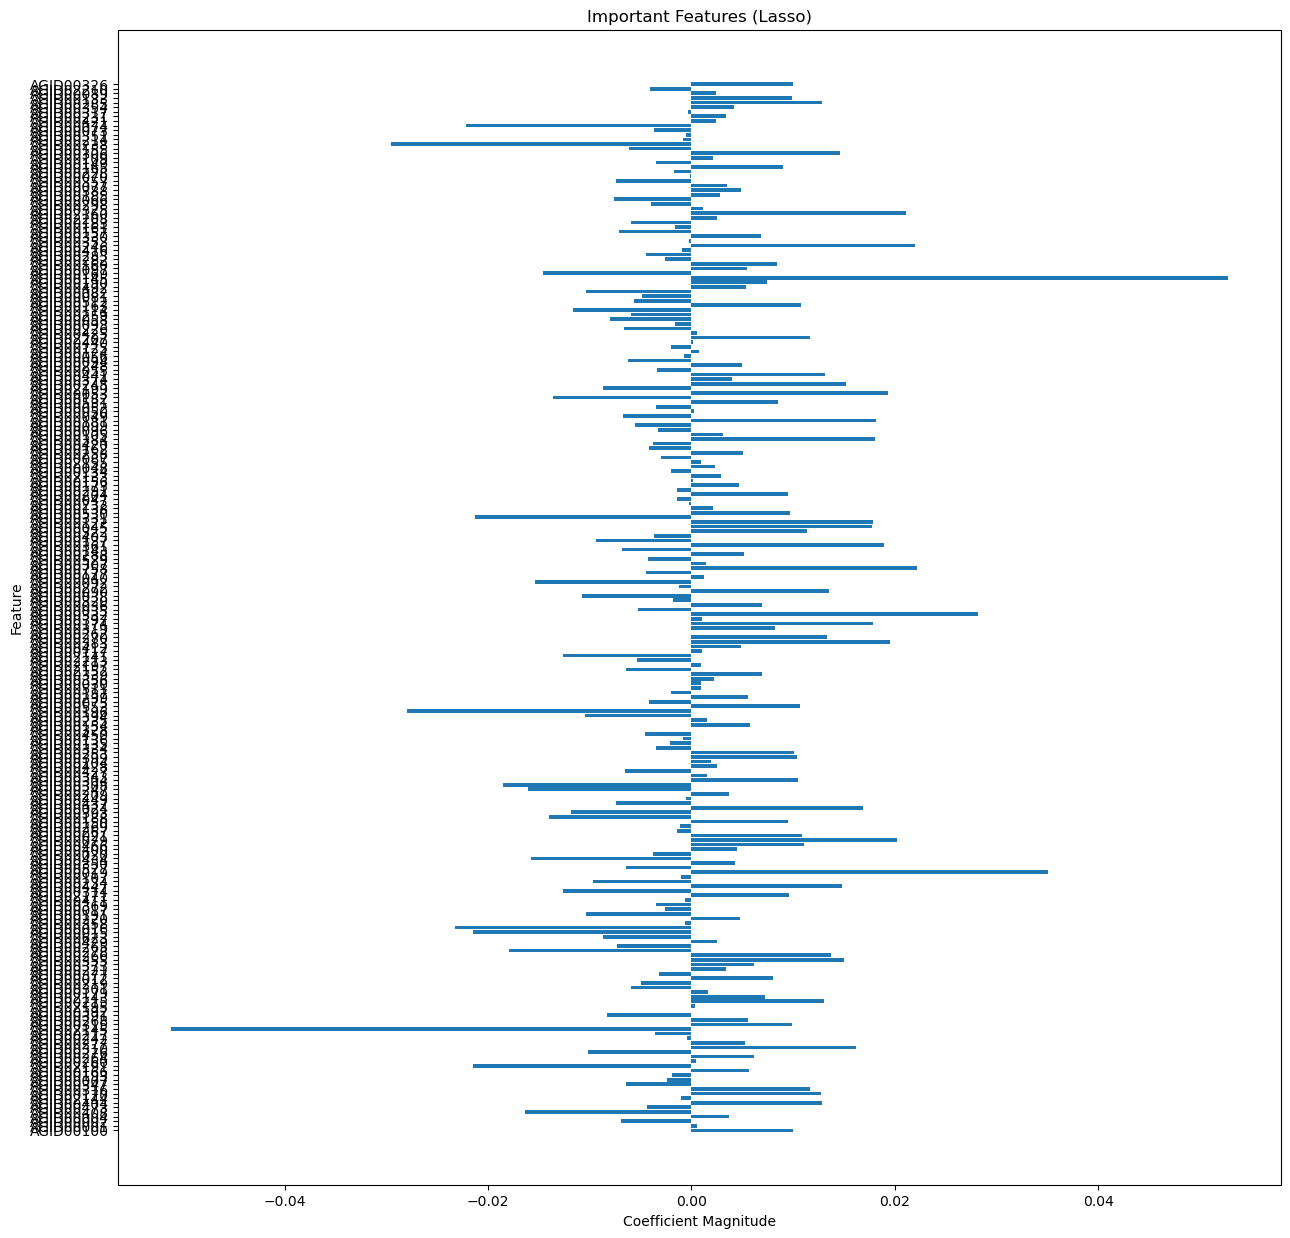

In [63]:
# Plot non-zero Lasso coefficients
plt.figure(figsize=(15, 15))
plt.barh(selected_features_lasso, lasso.coef_[lasso.coef_ != 0])
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Important Features (Lasso)")
plt.show()

## plot confusion matrix

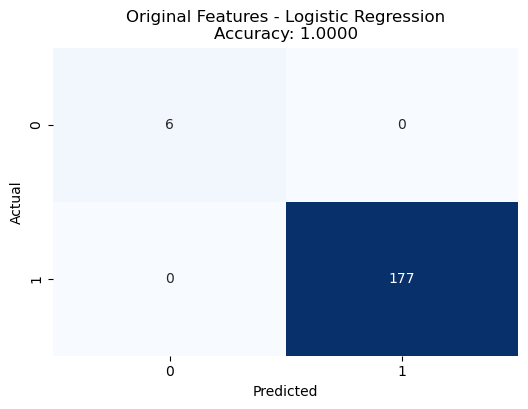

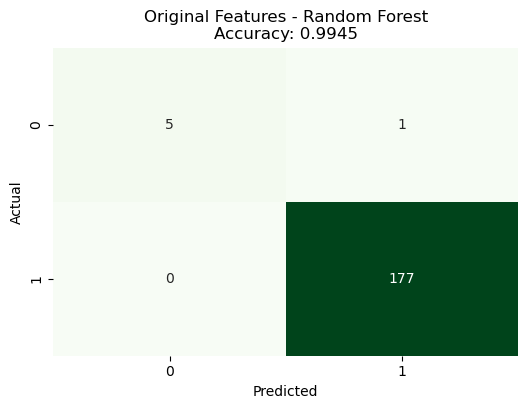

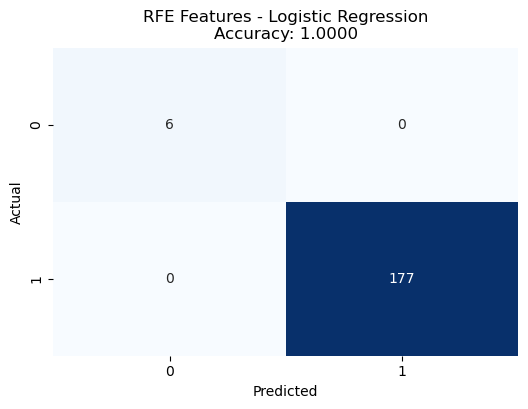

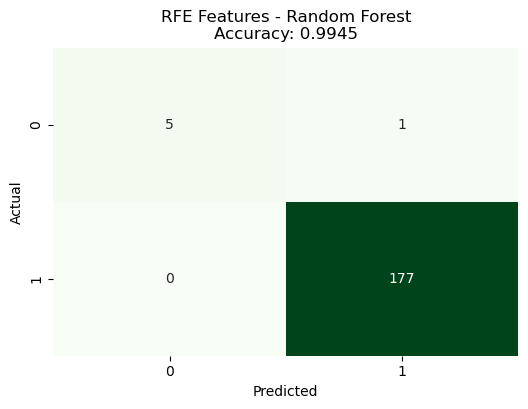

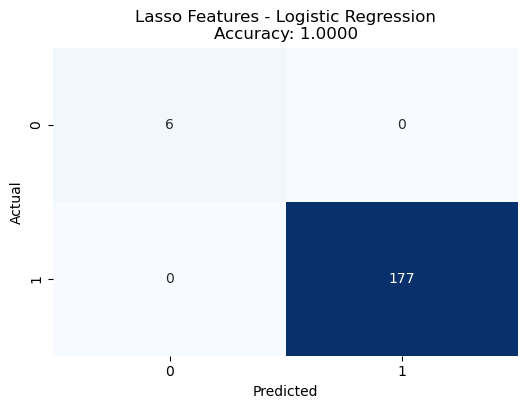

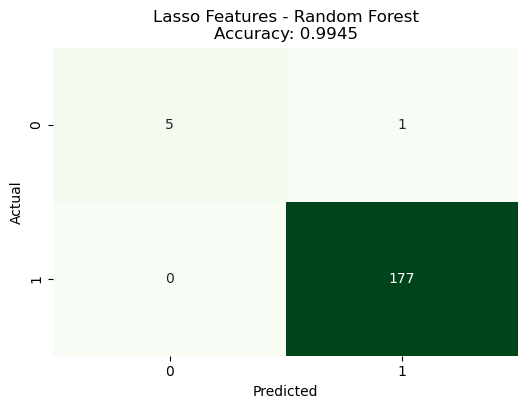

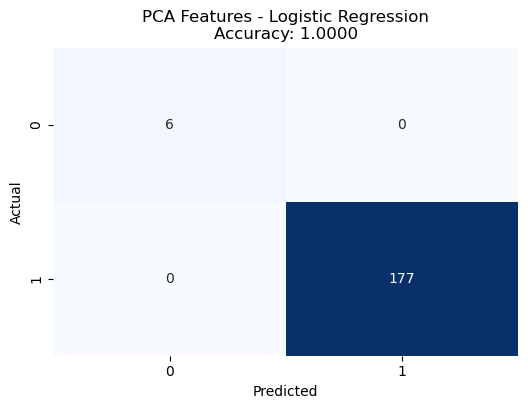

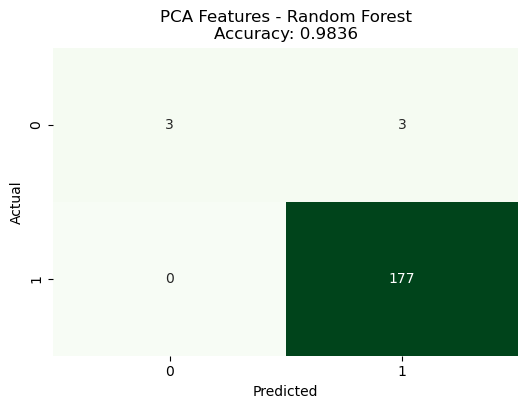

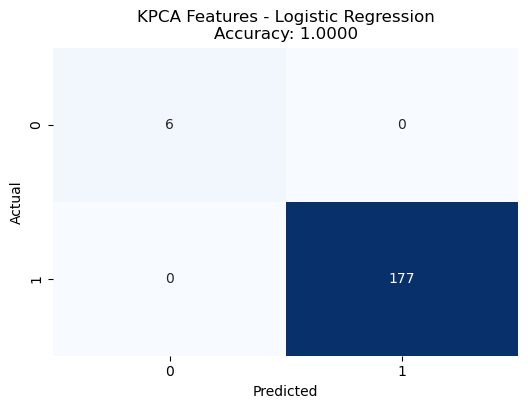

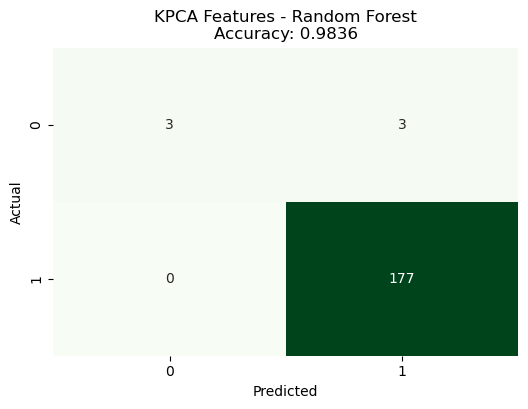

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_method(X_train, X_test, y_train, y_test, method_name):
    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    accuracy_lr = accuracy_score(y_test, y_pred_lr)

    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)

    cm_lr = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{method_name} - Logistic Regression\nAccuracy: {accuracy_lr:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    cm_rf = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False)
    plt.title(f"{method_name} - Random Forest\nAccuracy: {accuracy_rf:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy_lr, accuracy_rf

results = {}
results["Original Features"] = evaluate_method(X_train_scaled, X_test_scaled, y_train, y_test, "Original Features")
results["RFE Features"] = evaluate_method(X_train_rfe, X_test_rfe, y_train, y_test, "RFE Features")
results["Lasso Features"] = evaluate_method(X_train_lasso, X_test_lasso, y_train, y_test, "Lasso Features")
results["PCA Features"] = evaluate_method(X_train_pca, X_test_pca, y_train, y_test, "PCA Features")
results["KPCA Features"] = evaluate_method(X_train_kpca, X_test_kpca, y_train, y_test, "KPCA Features")
